In [13]:
# Example training data
import numpy as np  # Import numpy for numerical array operations

X_train = np.array([  # Create training features matrix with 10 samples and 2 features
    [6, 7], [2, 4], [7, 2], [3, 6], [4, 7],  # First 5 samples (class 0)
    [5, 2], [1, 6], [2, 0], [6, 3], [4, 1]   # Last 5 samples (class 1)
])
y_train = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])  # Binary labels: first 5 are class 0, last 5 are class 1

# Implement Decision Tree with scikit-learn
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Import decision tree classifier and visualization tool

tree_sk = DecisionTreeClassifier(criterion='gini', max_depth=2, min_samples_split=2, random_state=42)  # Create tree with Gini impurity, max depth of 2, minimum 2 samples to split
tree_sk.fit(X_train, y_train)  # Train the decision tree on training data

DecisionTreeClassifier(max_depth=2, random_state=42)

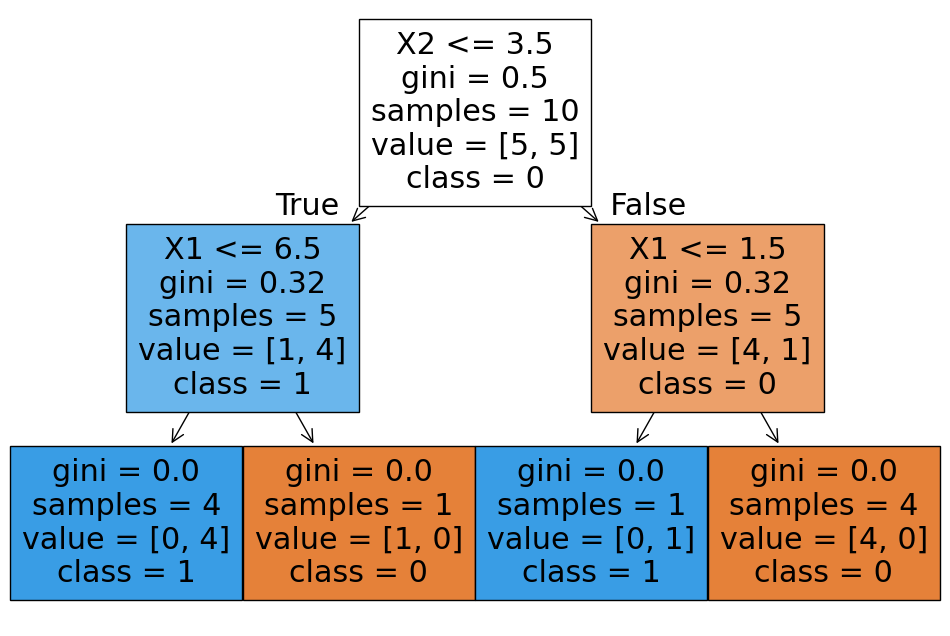

In [14]:
# Visualize the tree
import matplotlib.pyplot as plt  # Import matplotlib for plotting

plt.figure(figsize=(12, 8))  # Create a figure with size 12x8 inches
plot_tree(  # Plot the decision tree structure
    tree_sk,  # The trained decision tree model
    filled=True,  # Color nodes based on majority class
    feature_names=['X1', 'X2'],  # Names for the two features
    class_names=['0', '1']  # Names for the two classes
)
plt.show()  # Display the tree visualization

In [15]:
# Load the dataset (update the path to your local train.csv)
import pandas as pd  # Import pandas for data handling

df = pd.read_csv("train.csv")  # Load CSV file containing click prediction data
df.head()  # Display first 5 rows of the dataset

# Separate target and features
y = df['click']  # Extract target variable (whether ad was clicked)
X = df.drop(columns=['click', 'id', 'hour', 'device_id', 'device_ip'], axis=1)  # Remove target and unnecessary identifier columns

# Sample size
print(X.shape, y.shape)  # Print dimensions: (number_of_samples, number_of_features) and (number_of_samples,)

# Train/test split
from sklearn.model_selection import train_test_split  # Import function for data splitting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42  # Split data: 80% train, 20% test with fixed seed
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Print shapes of all split datasets

# Encode categorical data using OneHotEncoder
from sklearn.preprocessing import OneHotEncoder  # Import one-hot encoder for categorical variables

# handle_unknown='ignore' prevents errors due to unseen categories in test data
enc = OneHotEncoder(handle_unknown='ignore')  # Create encoder that ignores unknown categories

# Fit on train and transform both train and test
X_train_enc = enc.fit_transform(X_train)  # Learn encoding from training data and transform
X_test_enc = enc.transform(X_test)  # Apply learned encoding to test data

print(X_train_enc.shape, X_test_enc.shape)  # Print shapes after encoding (features will be expanded)

(300000, 19) (300000,)
(240000, 19) (60000, 19) (240000,) (60000,)
(240000, 8163) (60000, 8163)


In [18]:
# Decision Tree: evaluate different max_depth values
from sklearn.tree import DecisionTreeClassifier  # Import decision tree classifier
from sklearn.metrics import accuracy_score, roc_auc_score  # Import evaluation metrics

max_depth_values = [3, 10, None]  # Test three depth values: shallow (3), medium (10), and unlimited (None)

  # Loop through each depth value
decision_tree = DecisionTreeClassifier(  # Create decision tree with specific parameters
        criterion='gini',  # Use Gini impurity for splitting
        max_depth=10,  # Current depth being tested
        min_samples_split=30,  # Require at least 30 samples to split a node
        random_state=42  # Fixed seed for reproducibility
    )
decision_tree.fit(X_train_enc, y_train)  # Train tree on training data

y_pred = decision_tree.predict(X_test_enc)  # Make predictions on test data
y_proba = decision_tree.predict_proba(X_test_enc)[:, 1]  # Get probability of positive class

  # Print current depth value
print("Accuracy:", accuracy_score(y_test, y_pred))  # Print accuracy score
print("ROC AUC:", roc_auc_score(y_test, y_proba))  # Print ROC-AUC score
# Grid Search for Decision Tree hyperparameters
from sklearn.model_selection import GridSearchCV  # Import grid search for hyperparameter tuning

parameters = {  # Define parameter grid to search
    'max_depth': [3, 10, None],  # Different depth values to try
    'min_samples_split': [30]  # add more values if needed (e.g., 30, 40, 50)
}

grid_search = GridSearchCV(  # Create grid search object
    decision_tree,  # Base model
    parameters,  # Parameter combinations to test
    cv=3,  # 3-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC score
    n_jobs=-1  # Use all available CPU cores
)

grid_search.fit(X_train_enc, y_train)  # Find best parameters
print("Best parameters:", grid_search.best_params_)  # Display optimal parameters
print("Best ROC AUC score:", grid_search.best_score_)  # Display best cross-validation score

Accuracy: 0.8331333333333333
ROC AUC: 0.7116989240089078
Best parameters: {'max_depth': 10, 'min_samples_split': 30}
Best ROC AUC score: 0.7101285551791959


In [ ]:
# Random Forest implementation and tuning
from sklearn.ensemble import RandomForestClassifier  # Import random forest classifier
from sklearn.metrics import accuracy_score, roc_auc_score  # Import evaluation metrics
from sklearn.model_selection import GridSearchCV  # Import grid search

random_forest = RandomForestClassifier(  # Create random forest model with detailed configuration
    n_estimators=200,          # Number of trees in the forest
    max_depth=10,              # Maximum depth of each tree
    criterion='gini',          # Splitting criterion (Gini impurity)
    min_samples_split=20,      # Minimum samples required to split internal node
    min_samples_leaf=5,        # Minimum samples required at leaf node
    max_features='sqrt',       # Number of features to consider at each split (square root of total)
    bootstrap=True,            # Use bootstrap sampling (sample with replacement)
    oob_score=True,            # Calculate out-of-bag score for validation
    n_jobs=-1,                 # Use all CPU cores for parallel processing
    random_state=42,           # Fixed seed for reproducibility
    class_weight='balanced'    # Automatically adjust weights for imbalanced classes
)

random_forest.fit(X_train_enc, y_train)  # Train the random forest on training data

y_pred_rf = random_forest.predict(X_test_enc)  # Make predictions on test data
y_proba_rf = random_forest.predict_proba(X_test_enc)[:, 1]  # Get probability predictions

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))  # Print accuracy score
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_proba_rf))  # Print ROC-AUC score

# Grid Search for Random Forest hyperparameters
param_grid = {  # Define parameter grid for tuning
    'n_estimators': [100, 150, 200],  # Different numbers of trees to try
    'max_depth': [10, 15, 20],  # Different maximum depths
    'min_samples_split': [10, 20, 30],  # Different minimum samples for splitting
    'max_features': ['sqrt', 'log2', 0.3],  # Different feature selection strategies
    'class_weight': ['balanced']  # Use balanced class weights
}

grid_search = GridSearchCV(  # Create grid search for random forest
    random_forest,  # Base model to tune
    param_grid,  # Parameter combinations to test
    cv=3,  # 3-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train_enc, y_train)  # Find best parameter combination
print("Best parameters:", grid_search.best_params_)  # Display optimal parameters
print("Best score:", grid_search.best_score_)  # Display best cross-validation score

In [20]:
from sklearn.ensemble import RandomForestClassifier  # Import random forest classifier
from sklearn.model_selection import GridSearchCV  # Import grid search tool
help(RandomForestClassifier)  # Display detailed documentation for RandomForestClassifier class

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(
 |      n_estimators=100,
 |      *,
 |      criterion='gini',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features='sqrt',
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to p

In [3]:
%pip install xgboost

import xgboost as xgb  # Import XGBoost library
from xgboost import XGBClassifier  # Import XGBoost classifier specifically



Note: you may need to restart the kernel to use updated packages.


In [2]:

help(XGBClassifier)  # Display detailed documentation for XGBClassifier class including all parameters and methods

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(sklearn.base.ClassifierMixin, XGBModel)
 |  XGBClassifier(
 |      *,
 |      objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic',
 |      **kwargs: Any
 |  ) -> None
 |
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |
 |  Parameters
 |  ----------
 |
 |      n_estimators : Optional[int]
 |          Number of boosting rounds.
 |
 |      max_depth :  typing.Optional[int]
 |
 |          Maximum tree depth for base learners.
 |
 |      max_leaves : typing.Optional[int]
 |
 |          Maximum number of leaves; 0 indicates no limit.
 |
 |      max_bin : typing.Optional[int]
 |
 |          If using histogram-based algorithm, maximum number of bins per feature
 |
 |      grow_policy : typing.Optional[str]
 |
 |          Tree growing policy.
 |

In [ ]:
# XGBoost implementation and tuning
import xgboost as xgb  # Import XGBoost library for gradient boosting
from sklearn.metrics import accuracy_score, roc_auc_score  # Import evaluation metrics
from sklearn.model_selection import RandomizedSearchCV  # Import randomized search for efficient hyperparameter tuning

# Note: XGBoost uses different parameter names than scikit-learn trees.
# (e.g., it does NOT support min_samples_split/min_samples_leaf)
xgb_model = xgb.XGBClassifier(  # Create XGBoost classifier with specific parameters
    n_estimators=200,  # Number of boosting rounds (trees to build)
    max_depth=10,  # Maximum depth of each tree
    learning_rate=0.1,  # Step size shrinkage to prevent overfitting
    subsample=0.8,        # Fraction of samples used per tree (row sampling)
    colsample_bytree=0.8, # Fraction of features used per tree (column sampling)
    reg_alpha=0.1,        # L1 regularization term on weights
    reg_lambda=1.0,       # L2 regularization term on weights
    random_state=42,  # Fixed seed for reproducibility
    n_jobs=-1,  # Use all CPU cores
    eval_metric='logloss'  # Evaluation metric during training (logarithmic loss)
)

# Train and evaluate
xgb_model.fit(X_train_enc, y_train)  # Train XGBoost model on training data
y_pred_xgb = xgb_model.predict(X_test_enc)  # Make binary predictions on test data
y_proba_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]  # Get probability of positive class

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))  # Print accuracy score
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_proba_xgb))  # Print ROC-AUC score

# Randomized Search to explore hyperparameters
param_distributions = {  # Define parameter distributions for random sampling
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Different learning rates to try
    'max_depth': [3, 4, 5, 6, 7],  # Different tree depths
    'min_child_weight': [1, 3, 5, 7],  # Minimum sum of instance weight needed in child
    'subsample': [0.6, 0.7, 0.8, 0.9],  # Different row sampling ratios
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],  # Different column sampling ratios
    'reg_alpha': [0, 0.01, 0.1, 1],  # Different L1 regularization values
    'reg_lambda': [0.1, 1, 10, 100]  # Different L2 regularization values
}

random_search = RandomizedSearchCV(  # Create randomized search object
    xgb_model,  # Base model to tune
    param_distributions,  # Parameter space to sample from
    n_iter=100,  # Number of random parameter combinations to try
    cv=3,  # 3-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC score
    n_jobs=-1,  # Use all CPU cores
    random_state=42  # Fixed seed for reproducibility
)

random_search.fit(X_train_enc, y_train)  # Search for best parameters
print('Best parameters:', random_search.best_params_)  # Display optimal parameter combination
print('Best score:', random_search.best_score_)  # Display best cross-validation score